# Лабораторна 4. Детекція об’єктів з YOLO
### Шальман Тимофій КА-35

**Мета:** зібрати/підготувати дані у форматі YOLO, навчити щонайменше дві різні архітектури/конфігурації YOLO (наприклад, YOLOv8n vs YOLOv8s, або YOLOv5s vs YOLOv8n; за бажанням додайте YOLOv7‑tiny/YOLOX‑nano) і порівняти якість та швидкість. Оцінити mAP@0.5 і mAP@0.5:0.95, провести інференс на власних зображеннях/відео.

## **Варіант 1:** COCO датасет: підмножина, data.yaml, навчити yolov8n vs yolov8s; порівняти mAP@0.5/0.5:0.95 та FPS.

## Завантаження датасету
[Roboflow: Coco Computer Vision Dataset](https://universe.roboflow.com/yanzhe-xie/coco-n6v8y)

In [2]:
!pip install roboflow --quiet

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="suYUCWoccL1aGGRqvEqG")
project = rf.workspace("yanzhe-xie").project("coco-n6v8y")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Coco-1 in yolov8:: 100%|██████████| 9991/9991 [00:03<00:00, 2535.70it/s]


In [4]:
!cd Coco-1/ && cat data.yaml

names:
- airplane
- apple
- backpack
- banana
- baseball bat
- baseball glove
- bear
- bed
- bench
- bicycle
- bird
- boat
- book
- bottle
- bowl
- broccoli
- bus
- cake
- car
- carrot
- cat
- cell phone
- chair
- clock
- couch
- cow
- cup
- dining table
- dog
- donut
- elephant
- fire hydrant
- fork
- frisbee
- giraffe
- hair drier
- handbag
- horse
- hot dog
- keyboard
- kite
- knife
- laptop
- microwave
- motorcycle
- mouse
- orange
- oven
- parking meter
- person
- pizza
- potted plant
- refrigerator
- remote
- sandwich
- scissors
- sheep
- sink
- skateboard
- skis
- snowboard
- spoon
- sports ball
- stop sign
- suitcase
- surfboard
- teddy bear
- tennis racket
- tie
- toaster
- toilet
- toothbrush
- traffic light
- train
- truck
- tv
- umbrella
- vase
- wine glass
- zebra
nc: 80
roboflow:
  license: CC BY 4.0
  project: coco-n6v8y
  url: https://universe.roboflow.com/yanzhe-xie/coco-n6v8y/dataset/1
  version: 1
  workspace: yanzhe-xie
test: ../test/images
train: ../train/images
va

## Підготовка моделі

In [5]:
!pip install ultralytics --quiet --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.6 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO
import torch
import time
import cv2
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
data_dir = "/content/Coco-1"

## Fine-tuning моделей

## YOLOv8n

In [ ]:
model_n = YOLO("yolov8n.pt")

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())

True
0


In [ ]:
results_n = model_n.train(
    data=f"{data_dir}/data.yaml",
    epochs=30,
    imgsz=512,
    batch=16,
    device=0,
    name="yolov8n_exp"
)

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Coco-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_exp2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

### Графік mAP@0.5/0.5:0.95

In [ ]:
last_yolov8n_exp_dir = "/content/runs/detect/yolov8n_exp"

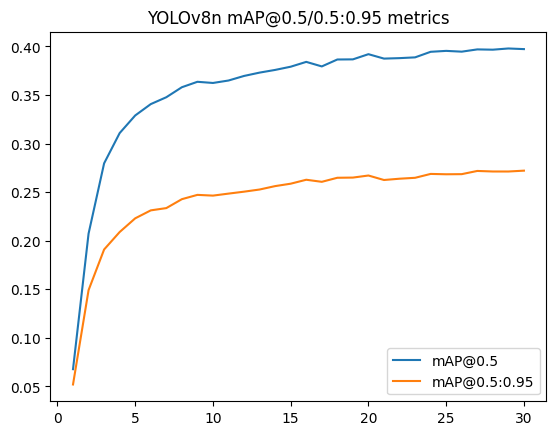

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(f"{last_yolov8n_exp_dir}/results.csv")

plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.legend()
plt.title("YOLOv8n mAP@0.5/0.5:0.95 metrics")
plt.show()

### Кількість параметрів, FLOPs та розмір ваг

In [ ]:
model_n.info()

Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


(73, 3151904, 0, 8.746444799999999)

In [ ]:
import os

size_mb = os.path.getsize(f"{last_yolov8n_exp_dir}/weights/best.pt") / (1024 * 1024)
print(f"Size: {size_mb:.2f} MB")

Size: 6.22 MB


### FPS/latency (CPU/GPU)
Беру перші 200 зображень з валідаційної вибірки.

In [ ]:
import numpy as np
import glob


images = glob.glob(f"{data_dir}/valid/images/*.jpg")
frames = [cv2.imread(p) for p in images[:200]]

# GPU

# warmup
for _ in range(10):
    model_n(frames[0], device=0, verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_n(frame, device=0, verbose=False)

    torch.cuda.synchronize()
    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.0089 sec
FPS: 111.99
Latency: 8.93 ms


In [ ]:
# CPU

# warmup
for _ in range(10):
    model_n(frames[0], device="cpu", verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_n(frame, device="cpu", verbose=False)

    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.1197 sec
FPS: 8.35
Latency: 119.71 ms


### Inference на власному фото

In [28]:
# try:
#   del model_n
# except:
#   pass

# torch.cuda.empty_cache()

In [29]:
# model_n = YOLO(f"{last_yolov8n_exp_dir}/weights/best.pt")

In [ ]:
results = model_n.predict(
    source="/content/test_img.jpg",
    save=True,
    conf=0.25
)

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/test_img.jpg"))

---
## YOLOv8s

In [ ]:
del model_n
torch.cuda.empty_cache()

In [8]:
model_s = YOLO("yolov8s.pt")

In [9]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())

True
0


In [10]:
results_s = model_s.train(
    data=f"{data_dir}/data.yaml",
    epochs=30,
    imgsz=512,
    batch=16,
    device=0,
    name="yolov8s_exp"
)

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Coco-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

### Графік mAP@0.5/0.5:0.95

In [15]:
last_yolov8s_exp_dir = "/content/runs/detect/yolov8s_exp"

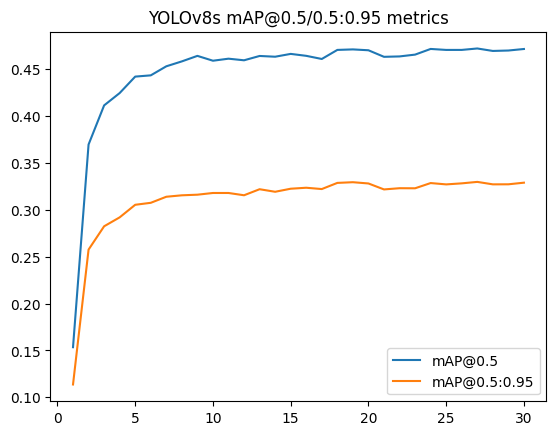

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(f"{last_yolov8s_exp_dir}/results.csv")

plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.legend()
plt.title("YOLOv8s mAP@0.5/0.5:0.95 metrics")
plt.show()

### Кількість параметрів, FLOPs та розмір ваг

In [13]:
model_s.info()

Model summary: 130 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(130, 11166560, 0, 28.816844800000002)

In [16]:
import os

size_mb = os.path.getsize(f"{last_yolov8s_exp_dir}/weights/best.pt") / (1024 * 1024)
print(f"Size: {size_mb:.2f} MB")

Size: 21.51 MB


### FPS/latency (CPU/GPU)
Беру перші 200 зображень з валідаційної вибірки.

In [20]:
import numpy as np
import glob


images = glob.glob(f"{data_dir}/valid/images/*.jpg")
frames = [cv2.imread(p) for p in images[:200]]

# GPU

# warmup
for _ in range(10):
    model_s(frames[0], device=0, verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_s(frame, device=0, verbose=False)

    torch.cuda.synchronize()
    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.0096 sec
FPS: 104.63
Latency: 9.56 ms


In [18]:
# CPU

# warmup
for _ in range(10):
    model_s(frames[0], device="cpu", verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_s(frame, device="cpu", verbose=False)

    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.2806 sec
FPS: 3.56
Latency: 280.55 ms


### Inference на власному фото

In [26]:
# try:
#   del model_s
# except:
#   pass

# torch.cuda.empty_cache()

In [24]:
# model_s = YOLO(f"{last_yolov8s_exp_dir}/weights/best.pt")

In [21]:
results = model_s.predict(
    source="/content/test_img.jpg",
    save=True,
    conf=0.25
)

Results saved to /content/runs/detect/predict


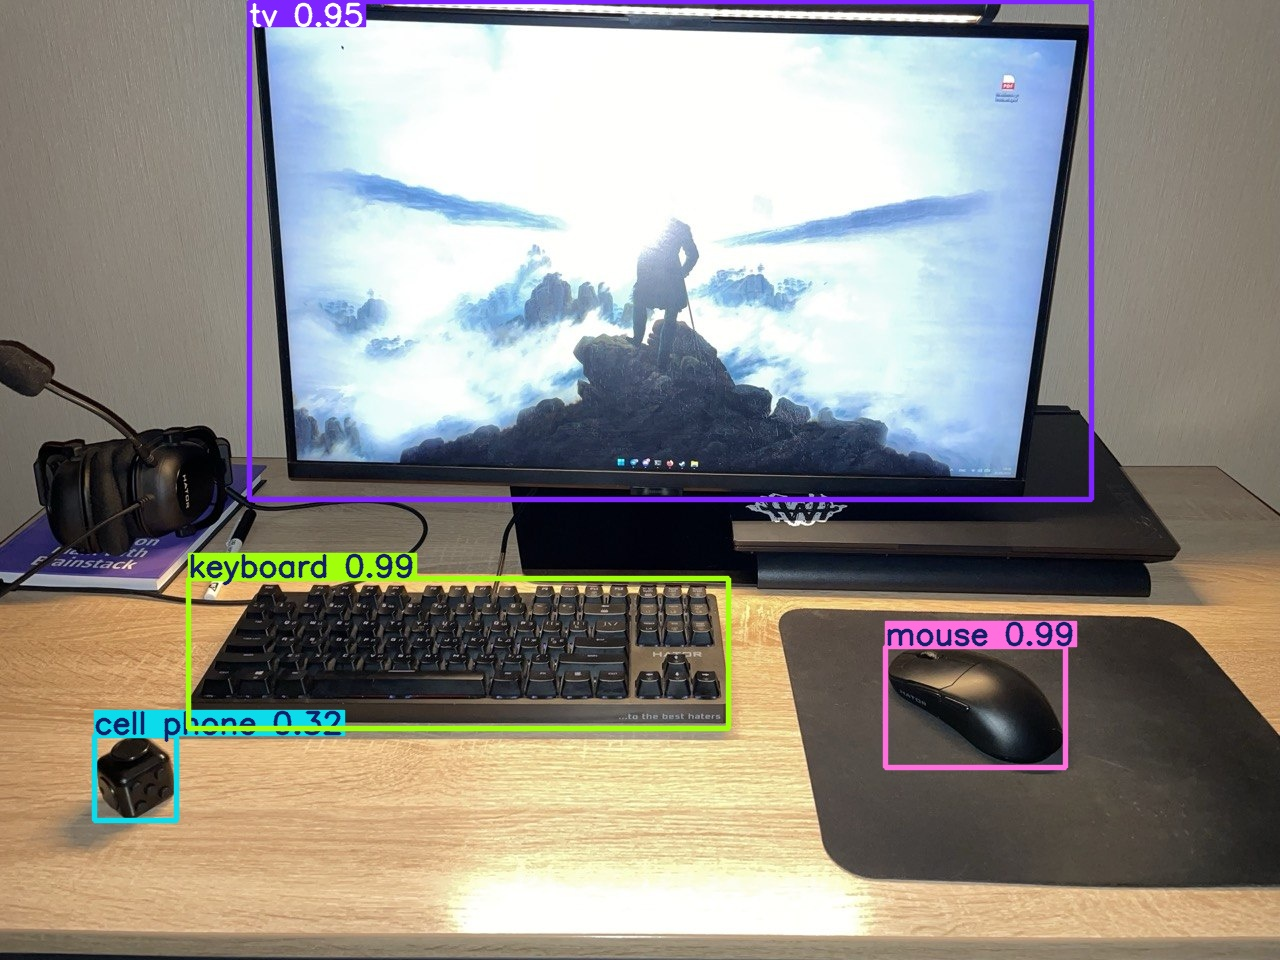

In [22]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/test_img.jpg"))

## Висновок

### Порівняння моделей YOLOv8n vs YOLOv8s

| Модель  | imgsz | Параметри (M) | FLOPs (G) | mAP@0.5 | mAP@0.5:0.95 | FPS (GPU) | FPS (CPU) | Розмір ваг |
|--------|------|--------------|-----------|--------|-------------|-----------|-----------|-----------|
| YOLOv8n | 512  | 3.15         | 8.7       | 0.397  | 0.272       | **111.99**    | **8.35**      | 6.22 MB   |
| YOLOv8s | 512  | **11.17**        | **28.8**     | **0.471**  | **0.329**       | 104.63    | 3.56      | **21.51 MB**  |

`YOLOv8s` демонструє кращу якість детекції (вищі mAP@0.5 та mAP@0.5:0.95) порівняно з `YOLOv8n`, що пояснюється більшою кількістю параметрів і обчислень (~3.5x більше FLOPs).

Водночас `YOLOv8n` значно швидша та легша модель: має менший розмір ваг, вищий FPS на CPU та трохи вищий FPS на GPU. Це робить її більш придатною для real-time застосувань та обмежених ресурсів.

Отже, `YOLOv8n` - кращий вибір для швидких систем (real-time), тоді як `YOLOv8s` - для задач, де важливіша точність.